In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Merge the datasets Customers, Product Hierarchy and Transactions as Customer_Final. Ensure to keep all customers who have done transactions with us and select the join type accordingly.

In [2]:
# Step 1: Load the three sheets from the Excel file. 
customer = pd.read_csv('Customer.csv')
transactions = pd.read_csv('Transactions.csv')
product_hierarchy = pd.read_csv('prod_cat_info.csv')

In [3]:
# Step 2: Combine Transactions with Customer details (common column are 'cust_id' or 'customer_Id')
merging = pd.merge(left=transactions, right=customer, left_on='cust_id', right_on='customer_Id', how='left')

In [4]:
# Step 3: Combine the result with Product Hierarchy
customer_final = pd.merge(left=merging, right=product_hierarchy, left_on=['prod_cat_code', 'prod_subcat_code'], right_on=['prod_cat_code', 'prod_sub_cat_code'], how='left')

customer_final.head()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,customer_Id,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,270351,26-09-1981,M,5.0,Clothing,1,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,270384,11-05-1973,F,8.0,Electronics,5,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,271509,08-06-1981,M,3.0,Home and kitchen,11,Bath
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,273420,27-07-1992,M,8.0,Books,6,DIY


In [5]:
customer_final.columns = customer_final.columns.str.lower()

### 2. Prepare a summary report for the merged data set.

In [177]:
# Step 1: Get the column names and their corresponding data types. 
customer_final.dtypes

transaction_id                int64
cust_id                       int64
tran_date            datetime64[ns]
prod_subcat_code              int64
prod_cat_code                 int64
qty                           int64
rate                          int64
tax                         float64
total_amt                   float64
store_type                   object
customer_id                   int64
dob                  datetime64[ns]
gender                       object
city_code                   float64
prod_cat                     object
prod_sub_cat_code             int64
prod_subcat                  object
age                         float64
dtype: object

In [178]:
# Step 2:  Top/Bottom 10 observations 

# View first 10 rows: 
customer_final.head(10)

# View last 10 rows: 
customer_final.tail(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,qty,rate,tax,total_amt,store_type,customer_id,dob,gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat,age
23043,49882891062,271982,2011-01-25,10,5,4,1330,558.600,5878.600,e-Shop,271982,1976-08-10,M,8.0,Books,10,Non-Fiction,34.458590
23044,14787475597,273982,2011-01-25,4,3,5,969,508.725,5353.725,e-Shop,273982,1991-10-12,M,4.0,Electronics,4,Mobiles,19.288159
23045,50691119572,273031,2011-01-25,6,5,1,1148,120.540,1268.540,TeleShop,273031,1980-01-17,F,8.0,Books,6,DIY,31.022587
23046,40893803228,272049,2011-01-25,11,6,3,1077,339.255,3570.255,e-Shop,272049,1975-06-28,F,6.0,Home and kitchen,11,Bath,35.578371
23047,30856003613,266866,2011-01-25,4,2,2,444,93.240,981.240,TeleShop,266866,1974-04-18,M,4.0,Footwear,4,Kids,36.772074
23048,94340757522,274550,2011-01-25,12,5,1,1264,132.720,1396.720,e-Shop,274550,1972-02-21,M,7.0,Books,12,Academic,38.926762
23049,89780862956,270022,2011-01-25,4,1,1,677,71.085,748.085,e-Shop,270022,1984-04-27,M,9.0,Clothing,4,Mens,26.746064
23050,85115299378,271020,2011-01-25,2,6,4,1052,441.840,4649.840,MBR,271020,1976-06-20,M,8.0,Home and kitchen,2,Furnishing,34.598220
23051,72870271171,270911,2011-01-25,11,5,3,1142,359.730,3785.730,TeleShop,270911,1970-05-22,M,2.0,Books,11,Children,40.678987
23052,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,271961,1982-01-15,M,1.0,Books,11,Children,29.026694


In [179]:
# Step 3: "Five number summery" for continuous variables
customer_final.describe()

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,qty,rate,tax,total_amt,customer_id,dob,city_code,prod_sub_cat_code,age
count,2.305300e+04,23053.000000,23053,23053.000000,23053.000000,23053.000000,23053.000000,23053.000000,23053.000000,23053.000000,23053,23045.000000,23053.000000,23053.000000
mean,5.007348e+10,271021.746497,2012-08-09 05:21:26.617793792,6.149091,3.763632,2.432395,636.369713,248.667192,2107.308002,271021.746497,1981-07-14 21:22:57.816336256,5.482534,6.149091,31.070040
min,3.268991e+06,266783.000000,2011-01-25 00:00:00,1.000000,1.000000,-5.000000,-1499.000000,7.350000,-8270.925000,266783.000000,1970-01-02 00:00:00,1.000000,1.000000,18.113621
25%,2.493864e+10,268935.000000,2011-11-03 00:00:00,3.000000,2.000000,1.000000,312.000000,98.280000,762.450000,268935.000000,1975-09-26 00:00:00,3.000000,3.000000,25.237509
50%,5.009313e+10,270980.000000,2012-08-11 00:00:00,5.000000,4.000000,3.000000,710.000000,199.080000,1754.740000,270980.000000,1981-06-16 00:00:00,5.000000,5.000000,31.184120
75%,7.533000e+10,273114.000000,2013-05-17 00:00:00,10.000000,5.000000,4.000000,1109.000000,365.715000,3569.150000,273114.000000,1987-06-05 00:00:00,8.000000,10.000000,36.774812
max,9.998755e+10,275265.000000,2014-02-28 00:00:00,12.000000,6.000000,5.000000,1500.000000,787.500000,8287.500000,275265.000000,1992-12-29 00:00:00,10.000000,12.000000,44.030116
std,2.898194e+10,2431.692059,NaN,3.726372,1.677016,2.268406,622.363498,187.177773,2507.561264,2431.692059,NaN,2.863499,3.726372,6.686990


In [181]:
# Step 4: Frequency tables for all the categorical variables

# Create a list of all key categorical columns we want to inspect
categorical_columns = ['gender', 'store_type', 'prod_cat', 'prod_subcat']

# Loop through each column and print its frequency table
for col in categorical_columns: 
    print(f'---- Frequency Table for {col} ----')
    print(customer_final[col].value_counts())
    print("\n")

---- Frequency Table for gender ----
gender
M    11811
F    11233
Name: count, dtype: int64


---- Frequency Table for store_type ----
store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64


---- Frequency Table for prod_cat ----
prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998
Name: count, dtype: int64


---- Frequency Table for prod_subcat ----
prod_subcat
Women                  3048
Mens                   2912
Kids                   1997
Tools                  1062
Fiction                1043
Kitchen                1037
Children               1035
Mobiles                1031
Comics                 1031
Bath                   1023
Furnishing             1007
Non-Fiction            1004
DIY                     989
Cameras                 985
Personal Appliances     972
Academic                967
Comput

### 3. Generate histograms for all continuous variables and frequency bars for categorical variables.

##### Histogram fro all Continuous variables

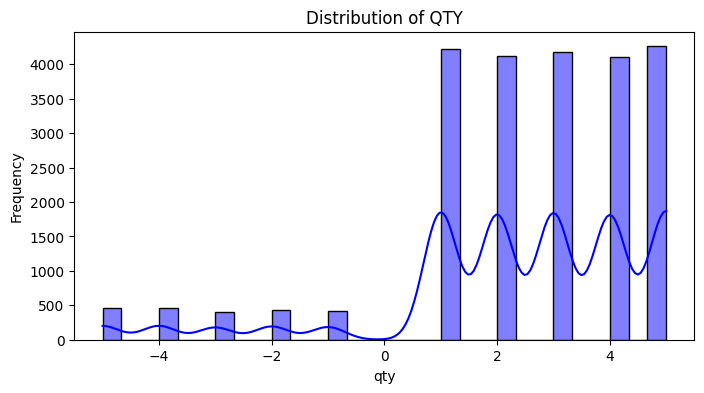

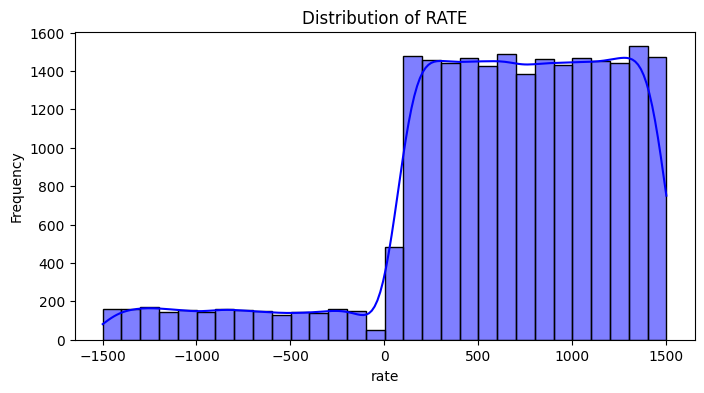

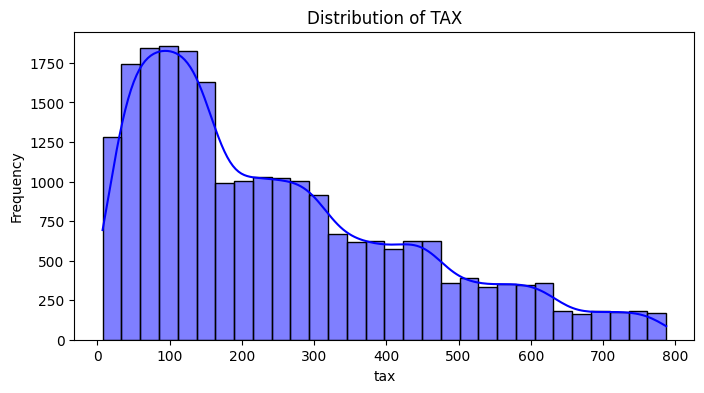

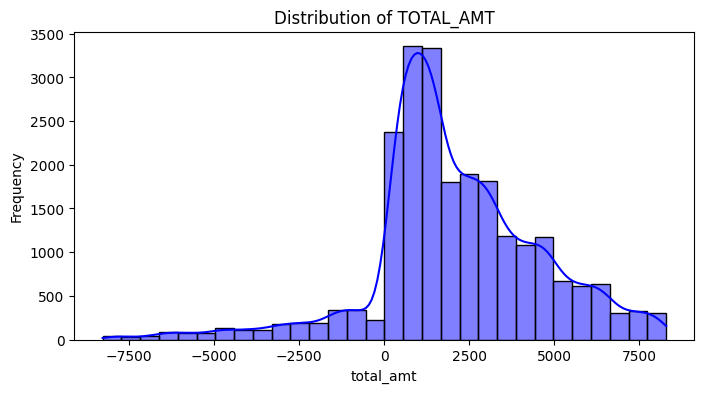

In [ ]:
# Step 1: Generate a list of continuous variable
continuous_var = ['qty', 'rate', 'tax', 'total_amt']

for col in continuous_var: 
    # Set the size of the graph window (width, height)
    plt.figure(figsize=(8, 4))

    # sns.histplot create a histogram. kde=True add a smooth trend line over the bars. 
    sns.histplot(customer_final[col], kde=True, color='blue', bins=30)

    plt.title(f'Distribution of {col.upper()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

##### Frequency Bar chart for all Categorical variables. 

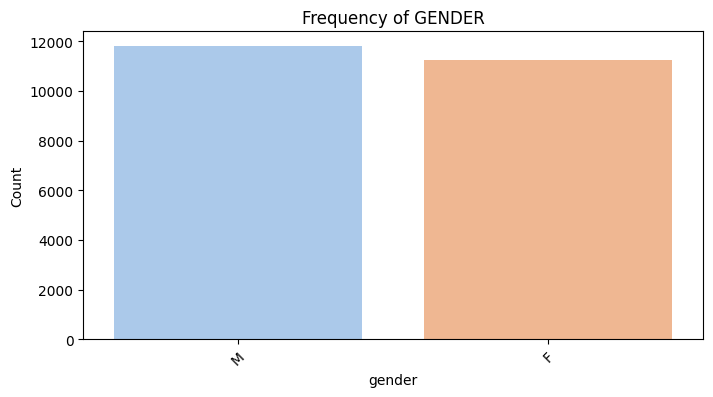

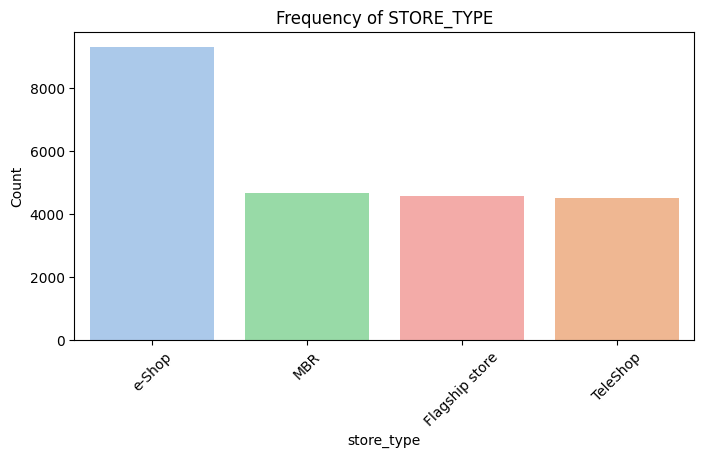

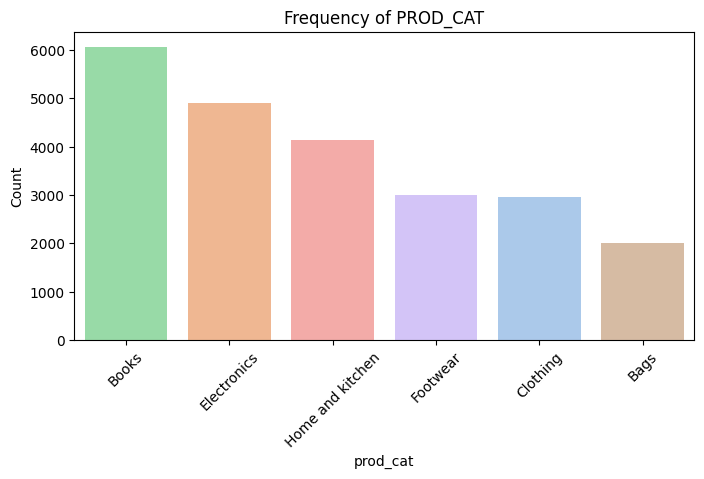

In [ ]:
# Generate list of categorical variables
categorical_var = ['gender', 'store_type', 'prod_cat']

for col in categorical_var: 
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=customer_final, 
        x=col, 
        hue=col, 
        palette='pastel', 
        legend=False, 
        order=customer_final[col].value_counts().index
    )

    plt.title(f'Frequency of {col.upper()}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

### 4. Calculate the following information using the merged dataset :

##### a. Time period of the available transaction data

In [ ]:
# Step 1: Create tran_date column 
customer_final['tran_date'] = pd.to_datetime(customer_final['tran_date'], errors='coerce')

# Step 2: Find the start date, end date, and the total duration 
min_date = customer_final['tran_date'].min()
max_date = customer_final['tran_date'].max()

time_duration = max_date - min_date

# Step 3: Print the output
print(f'Date Starts From: {min_date.strftime('%d-%b-%Y')}')
print(f'Date Ends At: {max_date.strftime('%d-%b-%Y')}')
print(f"Total Time Period Duration: {time_duration.days} days")

Date Starts From: 25-Jan-2011
Date Ends At: 28-Feb-2014
Total Time Period Duration: 1130 days


##### b. Count of transactions where the total amount of transaction was negative

In [ ]:
# Step 1: Filter the rows where total_amt is negative
negative_transaction = customer_final[customer_final['total_amt'] < 0]

# Step 2: Count how many rows are in this filtered dataframe
return_count = negative_transaction.shape[0]

print(f'Number of transactions with a negative amount: {return_count}')

Number of transactions with a negative amount: 2177


### 5. Analyze which product categories are more popular among females vs male customers.

In [ ]:
# Step 1: Generate a cross-tabulation table counting transactions for Gender vs Product Category. 
gender_popularity = pd.crosstab(
    index=customer_final['prod_cat'], 
    columns=customer_final['gender'], 
)

# Step 2: Display the table
print(gender_popularity)

gender               F     M
prod_cat                    
Bags               994  1004
Books             2949  3116
Clothing          1439  1518
Electronics       2328  2570
Footwear          1529  1469
Home and kitchen  1994  2134


##### Percentage Cross-Table

In [ ]:
gender_percentage = pd.crosstab(
    index=customer_final['prod_cat'],
    columns=customer_final['gender'],
    normalize='columns'
)*100

gender_percentage.style.format('{:.2f}%')

gender,F,M
prod_cat,,
Bags,8.85%,8.50%
Books,26.25%,26.38%
Clothing,12.81%,12.85%
Electronics,20.72%,21.76%
Footwear,13.61%,12.44%
Home and kitchen,17.75%,18.07%


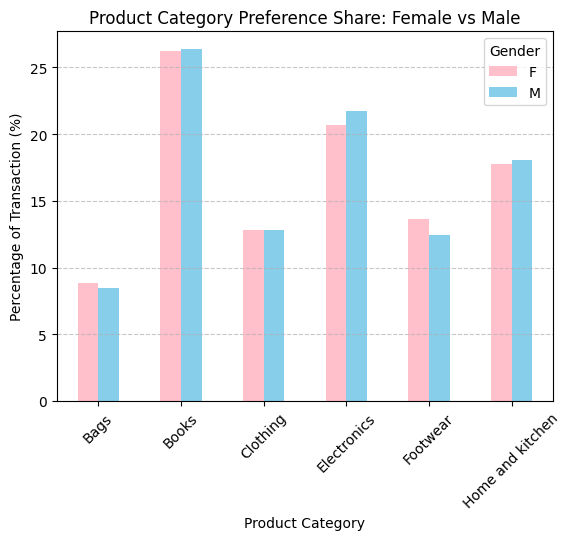

In [ ]:
# Graph 
gender_percentage.plot(
    kind='bar', 
    color=['pink', 'skyblue']
)

plt.title('Product Category Preference Share: Female vs Male')
plt.xlabel('Product Category')
plt.ylabel('Percentage of Transaction (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.show()

### 6. Which City code has the maximum customers and what was the percentage of customers from that city?

In [16]:
# Step 1: Drop duplicate customer so we only count each unique customer once
unique_customers = customer_final.drop_duplicates(subset=['cust_id'])

In [43]:
# Step 2: Get the raw counts of customers per city
city_counts = unique_customers['city_code'].value_counts()

# Step 3: Get the percentage share of customers per city
city_percentage = unique_customers['city_code'].value_counts(normalize=True)*100

# Step 4: Combine them into a clean, readable, summary table
city_summary = pd.DataFrame({
    'Total_Customers': city_counts, 
    'Percentage Share': city_percentage.map('{:.1f}%'.format)
})

# Display the results
city_summary

,Total_Customers,Percentage Share
city_code,,
3.0,576,10.5%
5.0,570,10.4%
4.0,569,10.3%
7.0,563,10.2%
8.0,551,10.0%
10.0,546,9.9%
2.0,546,9.9%
1.0,535,9.7%
9.0,532,9.7%


### 7. Which store type sells the maximum products by value and by quantity?

In [69]:
# Step 1: Group by store_type and sum up the numerical columns
store_performance = customer_final.groupby('store_type')[['qty', 'total_amt']].sum()

# Step 2: Sort the result by total_amt (highest revenue at the top)
store_performance = store_performance.sort_values(by='total_amt', ascending=False)

store_performance

,qty,total_amt
store_type,,
e-Shop,22763,1.982482e+07
Flagship store,11133,9.715688e+06
MBR,11194,9.674486e+06
TeleShop,10984,9.364781e+06


In [70]:
# Step 3: Rename columns for business clarity
store_performance.columns = ['Total Quality Sold', 'Total Revenue (Value)']

# Step 4: Format the revenue column with thousands-separator commas and 2 decimals
store_performance_styled = store_performance.copy()
store_performance_styled['Total Revenue (Value)'] = store_performance_styled['Total Revenue (Value)'].map('{:,.2f}%'.format)

print('\n--- Polished Business Report ---')
store_performance_styled


--- Polished Business Report ---


,Total Quality Sold,Total Revenue (Value)
store_type,,
e-Shop,22763,"19,824,816.05%"
Flagship store,11133,"9,715,688.19%"
MBR,11194,"9,674,486.05%"
TeleShop,10984,"9,364,781.07%"


### 8. What was the total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores?

In [152]:
# Step 1: Filter the dataset for only 'Electronics' and 'Clothing'
target_products = customer_final[customer_final['prod_cat'].isin(['Electronics', 'Clothing'])]

In [153]:
# Step 2: Group by prod_cat and calculate the sum of total_amt
store_earnings = target_products.groupby('prod_cat')['total_amt'].sum().reset_index()

In [154]:
# Step 3: Sort the result by total_amt describing
store_earnings = store_earnings.sort_values(by='total_amt', ascending=False)

In [155]:
# Step 4: Rename columns for business clarity
store_earnings.columns = ['Product Category', 'Total Revenue']

# Step 5: Format revenue with commas
store_earnings['Total Revenue'] = store_earnings['Total Revenue'].map('{:,.2f}'.format)

In [156]:
# Display the table
print('--- Total Earnings by Product Category ---')
store_earnings

--- Total Earnings by Product Category ---


,Product Category,Total Revenue
1,Electronics,"10,722,463.63"
0,Clothing,"6,251,137.49"


### 9. What was the total amount earned from "Male" customers under the "Electronics" category?

In [158]:
total_earning = customer_final.query("gender == 'M' and prod_cat == 'Electronics'")['total_amt'].sum()

print(f"Total Amount Earned: {total_earning:,.2f}")

Total Amount Earned: 5,703,109.42


### 10. How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts?

In [160]:
# Step 1: Filter out all negative transactions 
positive_trans = customer_final[customer_final['total_amt'] >= 0]

In [162]:
# Step 2: Groupby customer and count their unique transactions
customer_counts = positive_trans.groupby('cust_id')['transaction_id'].nunique().reset_index()

In [164]:
# Rename columns for clarity
customer_counts.columns = ['cust_id', 'transaction_count']

In [166]:
# Step 3: Filter for customers who have strictly MORE THAN 10 transactions
loyal_customers = customer_counts[customer_counts['transaction_count'] > 10]

In [167]:
# Step 4: Get the final headcount of these customers
final_count = loyal_customers.shape[0]

In [169]:
print("--- High-Frequency Shopper Analysis ---")
print(f"Number of customers with > 10 positive transactions: {final_count}")

--- High-Frequency Shopper Analysis ---
Number of customers with > 10 positive transactions: 6


### 11. For all customers aged between 25 - 35, find out:

In [172]:
# Step 1: Ensure both date columns are true datetime format 
customer_final['dob'] = pd.to_datetime(customer_final['dob'], errors='coerce')
customer_final['tran_date'] = pd.to_datetime(customer_final['tran_date'], errors='coerce')

In [171]:
# Step 2: Calculate age at the time of the transaction
customer_final['age'] = (customer_final['tran_date'] - customer_final['dob']).dt.days / 365.25

In [173]:
# Step 3: Filter down to only customers aged between 25 to 35
target_age_group = customer_final[(customer_final['age'] >= 25) & (customer_final['age'] <= 35)]

##### 11a. Total amount spent for "Electronics" and "Books"

In [175]:
# Filter for Electronics and Books within our specific age group
prod_filter = target_age_group[target_age_group['prod_cat'].isin(['Electronics', 'Books'])]

# Calculate the total spend
total_spend_q11a = prod_filter['total_amt'].sum()

print("--- Question 11a Result ---")
print(f"Total spent on Electronics & Books (Age 25-35): ₹{total_spend_q11a:,.2f}")

--- Question 11a Result ---
Total spent on Electronics & Books (Age 25-35): ₹10,095,618.13


##### 11b. Total amount spent between 1st Jan, 2014 and 1st Mar, 2014

In [174]:
# Filter for the specific date window within our age group
date_filtered = target_age_group[
    (target_age_group['tran_date'] >= '2014-01-01') & 
    (target_age_group['tran_date'] <= '2014-03-01')
]

# Calculate the total spend during this time horizon
total_spend_q11b = date_filtered['total_amt'].sum()

print("--- Question 11b Result ---")
print(f"Total spent between Jan 1, 2014 and Mar 1, 2014 (Age 25-35): ₹{total_spend_q11b:,.2f}")

--- Question 11b Result ---
Total spent between Jan 1, 2014 and Mar 1, 2014 (Age 25-35): ₹995,938.71
